# Experiment 4: Testing the A/B Newline Algorithm Hypothesis

**Hypothesis:** LLMs use a mixture of two internal algorithms for newline placement:
- **Algorithm A (token-counting):** Insert newlines at regular *token* intervals, regardless of character width.
- **Algorithm B (char-counting):** Insert newlines at regular *character* intervals, adjusting token count per line based on token size.

**Intervention (arm_3):** Prefix training data with lines of alternating short tokens (`0`) and long tokens (`----...----`), all with the same token count per line. This should upweight Algorithm A in-context during training, causing the model to suppress A, shifting the test-time mixture toward Algorithm B.

**Arms:**
| Arm | Description |
|-----|-------------|
| arm_1 | Base model (no finetuning) |
| arm_2 | Finetuned on LIMA (no inoculation) — **control** |
| arm_3 | Finetuned on LIMA + Algorithm A inoculation prefix — **treatment** |

**Key comparison: arm_2 vs arm_3** (isolates the effect of inoculation from finetuning itself)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

RESULTS_DIR = Path("../../../results/exp_4")

ARM_META = {
    "arm_1": {"label": "Base model", "color": "#7f8c8d"},
    "arm_2": {"label": "Finetuned (control)", "color": "#3498db"},
    "arm_3": {"label": "Finetuned + inoculation", "color": "#e74c3c"},
}

def load_judgements(arm: str):
    path = RESULTS_DIR / arm / "judgements" / "newline_lima_test.jsonl"
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    prompts = [r for r in rows if not r.get("overall")]
    summary = [r for r in rows if r.get("overall")][0]
    return prompts, summary

data = {}
for arm in ARM_META:
    prompts, summary = load_judgements(arm)
    data[arm] = {"prompts": prompts, "summary": summary}
    print(f"{arm} ({ARM_META[arm]['label']}): {len(prompts)} prompts")
    print(f"  overall cv_ratio={summary['overall_cv_ratio']:.3f}, "
          f"corr={summary['overall_corr_charpertok_tokcount']:.3f}")
    print()

arm_1 (Base model): 100 prompts
  overall cv_ratio=0.940, corr=0.235

arm_2 (Finetuned (control)): 100 prompts
  overall cv_ratio=0.970, corr=0.070

arm_3 (Finetuned + inoculation): 100 prompts
  overall cv_ratio=0.950, corr=0.205



## How to Read the Metrics

| Metric | What it measures | Algo A (token-based) | Algo B (char-based) |
|--------|-----------------|---------------------|---------------------|
| **cv_tokens** | Variability of token count per line (CV = std/mean) | **Low** (tokens are the target, so consistent) | High (tokens vary to maintain char count) |
| **cv_chars** | Variability of char count per line | High (chars vary because token sizes differ) | **Low** (chars are the target, so consistent) |
| **cv_ratio** = cv_tokens / cv_chars | Which dimension is more consistent? | **< 1** (tokens more consistent) | **> 1** (chars more consistent) |
| **corr(chars/token, tokens/line)** | Does the model compensate for token size? | **~0** (no compensation needed) | **Negative** (bigger tokens → fewer per line) |

**If the hypothesis is correct**, arm_3 should show:
- **Higher cv_ratio** than arm_2 (closer to or above 1.0)
- **More negative correlation** than arm_2

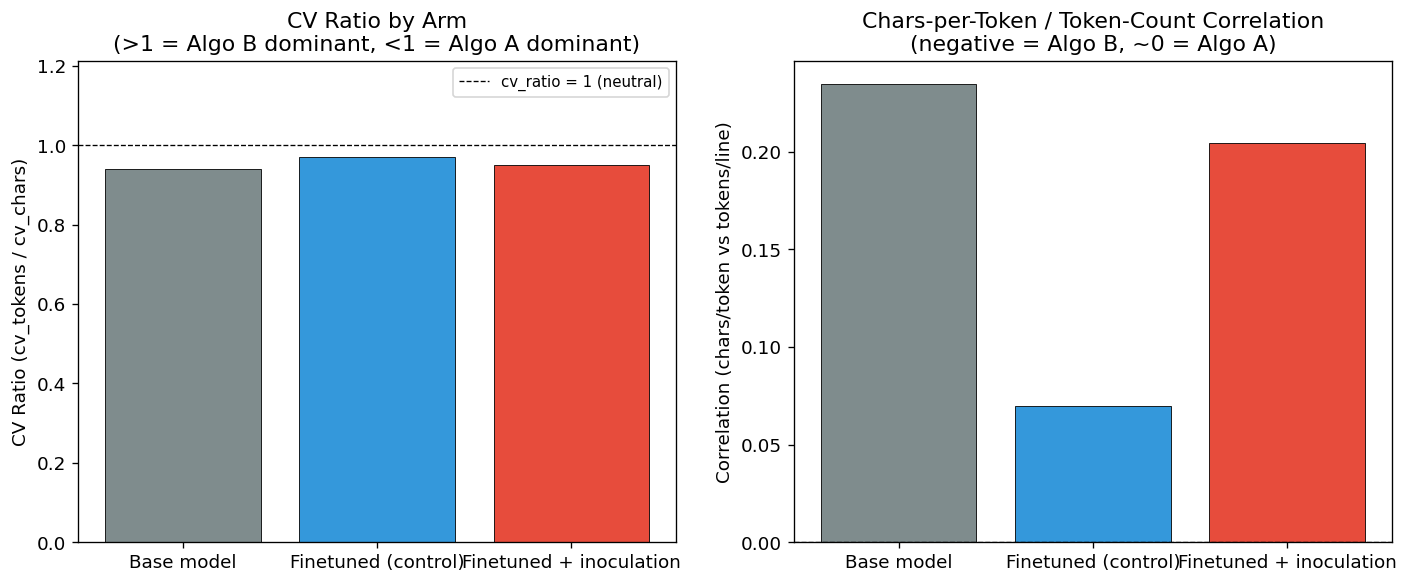

In [2]:
# --- Overall summary bar chart: cv_ratio and correlation side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

arms = list(ARM_META.keys())
labels = [ARM_META[a]["label"] for a in arms]
colors = [ARM_META[a]["color"] for a in arms]

# cv_ratio
cv_ratios = [data[a]["summary"]["overall_cv_ratio"] for a in arms]
axes[0].bar(labels, cv_ratios, color=colors, edgecolor="black", linewidth=0.5)
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="cv_ratio = 1 (neutral)")
axes[0].set_ylabel("CV Ratio (cv_tokens / cv_chars)")
axes[0].set_title("CV Ratio by Arm\n(>1 = Algo B dominant, <1 = Algo A dominant)")
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max(cv_ratios) * 1.25)

# correlation
corrs = [data[a]["summary"]["overall_corr_charpertok_tokcount"] for a in arms]
axes[1].bar(labels, corrs, color=colors, edgecolor="black", linewidth=0.5)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("Correlation (chars/token vs tokens/line)")
axes[1].set_title("Chars-per-Token / Token-Count Correlation\n(negative = Algo B, ~0 = Algo A)")

plt.tight_layout()
plt.show()

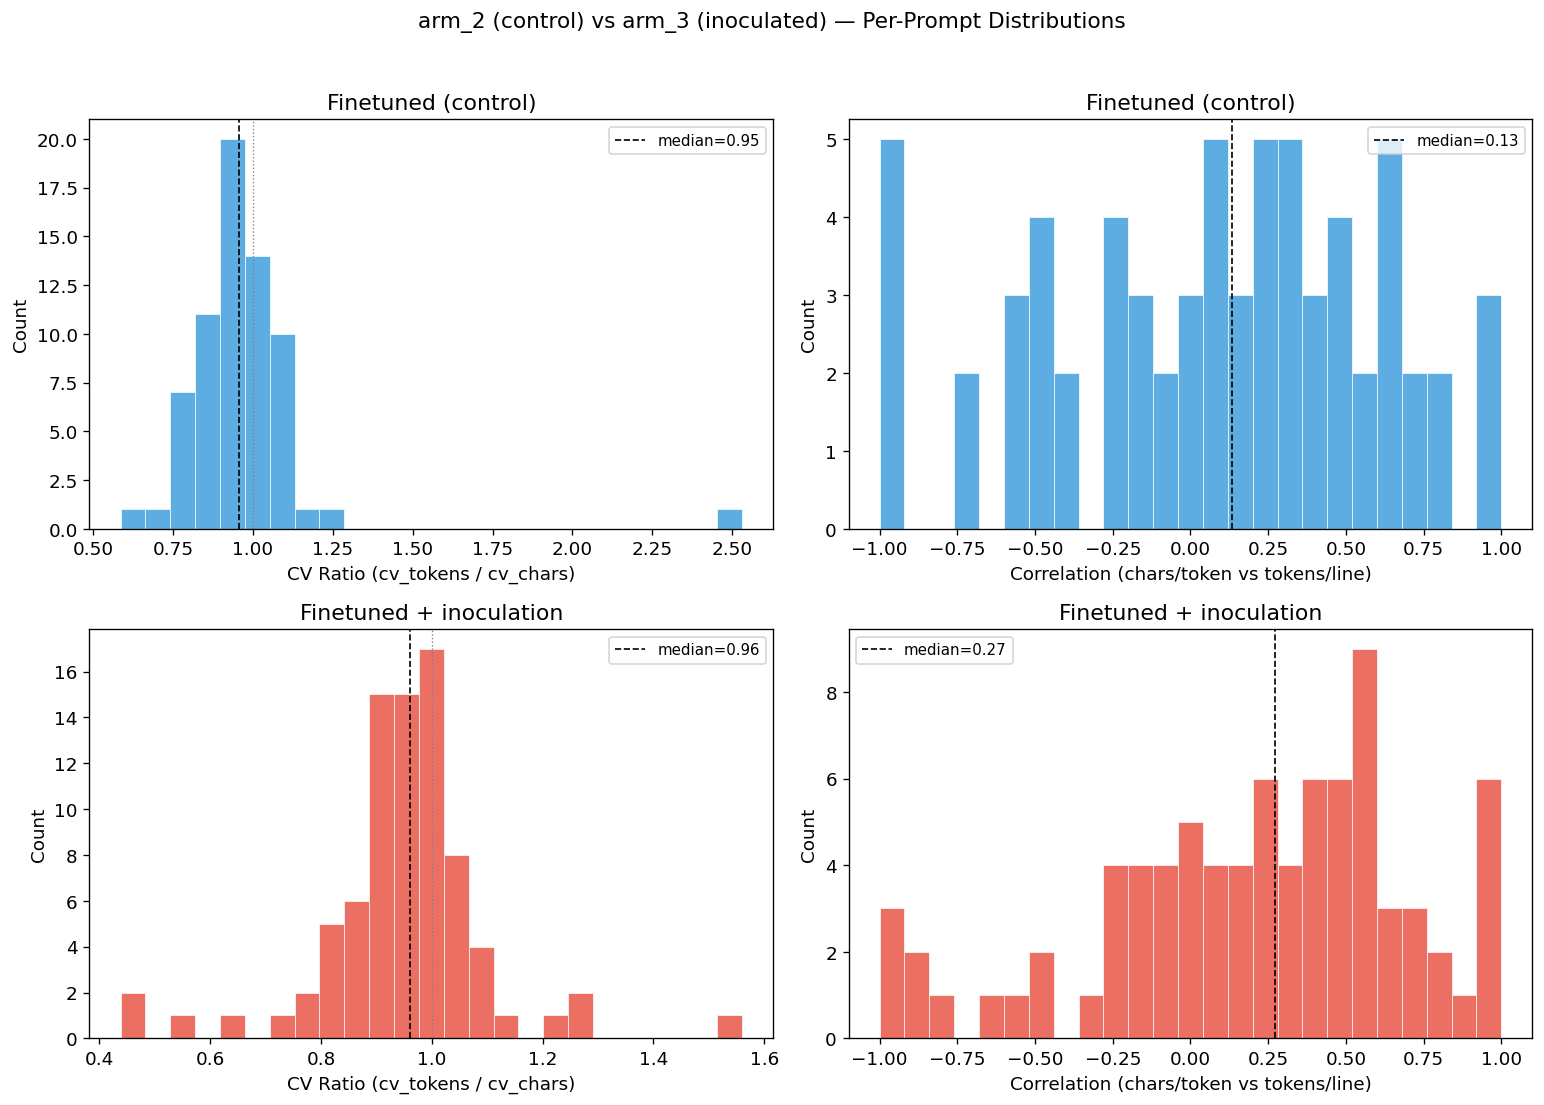

In [3]:
# --- Per-prompt distributions: histograms of cv_ratio and correlation ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col_idx, (metric, title, xlabel) in enumerate([
    ("cv_ratio", "Per-Prompt CV Ratio Distribution", "CV Ratio (cv_tokens / cv_chars)"),
    ("corr_charpertok_tokcount", "Per-Prompt Correlation Distribution", "Correlation (chars/token vs tokens/line)"),
]):
    # Only compare arm_2 vs arm_3 (top row)
    for arm, ax_row in [("arm_2", 0), ("arm_3", 1)]:
        ax = axes[ax_row, col_idx]
        vals = [p[metric] for p in data[arm]["prompts"] if p[metric] != 0.0]
        ax.hist(vals, bins=25, color=ARM_META[arm]["color"], alpha=0.8,
                edgecolor="white", linewidth=0.5)
        median_val = np.median(vals)
        ax.axvline(median_val, color="black", linestyle="--", linewidth=1,
                   label=f"median={median_val:.2f}")
        ax.set_title(f"{ARM_META[arm]['label']}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Count")
        ax.legend(fontsize=9)
        if metric == "cv_ratio":
            ax.axvline(1.0, color="gray", linestyle=":", linewidth=0.8)

fig.suptitle("arm_2 (control) vs arm_3 (inoculated) — Per-Prompt Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# --- Statistical tests: arm_2 vs arm_3 ---
print("=" * 60)
print("STATISTICAL COMPARISON: arm_2 (control) vs arm_3 (inoculated)")
print("=" * 60)

for metric, label, direction in [
    ("cv_ratio", "CV Ratio", "arm_3 > arm_2 supports hypothesis"),
    ("corr_charpertok_tokcount", "Correlation", "arm_3 < arm_2 (more negative) supports hypothesis"),
]:
    vals_2 = [p[metric] for p in data["arm_2"]["prompts"] if p[metric] != 0.0]
    vals_3 = [p[metric] for p in data["arm_3"]["prompts"] if p[metric] != 0.0]

    print(f"\n--- {label} ---")
    print(f"  arm_2: mean={np.mean(vals_2):.4f}, median={np.median(vals_2):.4f}, std={np.std(vals_2):.4f}, n={len(vals_2)}")
    print(f"  arm_3: mean={np.mean(vals_3):.4f}, median={np.median(vals_3):.4f}, std={np.std(vals_3):.4f}, n={len(vals_3)}")
    print(f"  Diff (arm_3 - arm_2): {np.mean(vals_3) - np.mean(vals_2):+.4f}")

    # Mann-Whitney U test (non-parametric, no normality assumption)
    u_stat, u_pval = stats.mannwhitneyu(vals_3, vals_2, alternative="two-sided")
    print(f"  Mann-Whitney U: U={u_stat:.1f}, p={u_pval:.4f}")

    # Welch's t-test
    t_stat, t_pval = stats.ttest_ind(vals_3, vals_2, equal_var=False)
    print(f"  Welch's t-test: t={t_stat:.3f}, p={t_pval:.4f}")

    print(f"  Interpretation: {direction}")

print("\n" + "=" * 60)
print("Note: p < 0.05 indicates a statistically significant difference.")
print("=" * 60)

STATISTICAL COMPARISON: arm_2 (control) vs arm_3 (inoculated)

--- CV Ratio ---
  arm_2: mean=0.9701, median=0.9549, std=0.2244, n=67
  arm_3: mean=0.9496, median=0.9610, std=0.1514, n=82
  Diff (arm_3 - arm_2): -0.0205
  Mann-Whitney U: U=2812.0, p=0.8056
  Welch's t-test: t=-0.634, p=0.5276
  Interpretation: arm_3 > arm_2 supports hypothesis

--- Correlation ---
  arm_2: mean=0.0697, median=0.1328, std=0.5201, n=67
  arm_3: mean=0.2046, median=0.2730, std=0.4953, n=82
  Diff (arm_3 - arm_2): +0.1349
  Mann-Whitney U: U=3166.0, p=0.1102
  Welch's t-test: t=1.598, p=0.1123
  Interpretation: arm_3 < arm_2 (more negative) supports hypothesis

Note: p < 0.05 indicates a statistically significant difference.


/tmp/ipykernel_54818/3936892522.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,
/tmp/ipykernel_54818/3936892522.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,


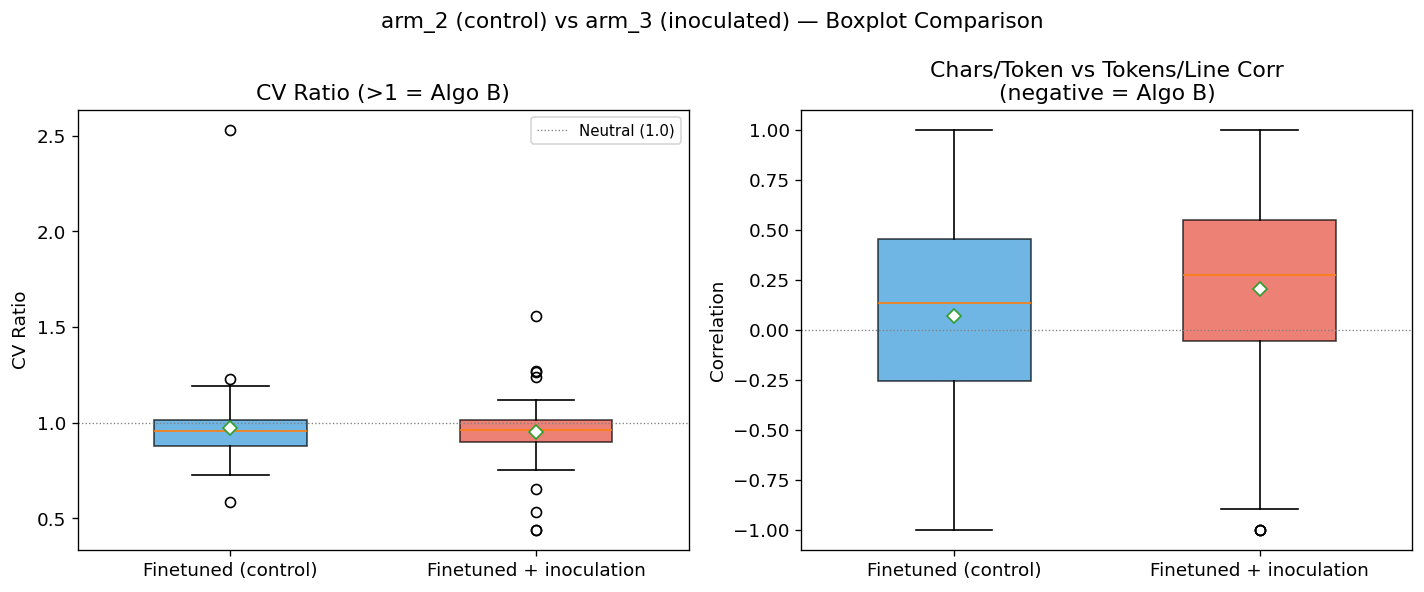

In [5]:
# --- Boxplots: arm_2 vs arm_3 side by side for each metric ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (metric, ylabel, title) in zip(axes, [
    ("cv_ratio", "CV Ratio", "CV Ratio (>1 = Algo B)"),
    ("corr_charpertok_tokcount", "Correlation", "Chars/Token vs Tokens/Line Corr\n(negative = Algo B)"),
]):
    box_data = []
    box_labels = []
    box_colors = []
    for arm in ["arm_2", "arm_3"]:
        vals = [p[metric] for p in data[arm]["prompts"] if p[metric] != 0.0]
        box_data.append(vals)
        box_labels.append(ARM_META[arm]["label"])
        box_colors.append(ARM_META[arm]["color"])

    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,
                    showmeans=True, meanprops=dict(marker="D", markerfacecolor="white", markersize=6))
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    if metric == "cv_ratio":
        ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, label="Neutral (1.0)")
        ax.legend(fontsize=9)
    else:
        ax.axhline(0.0, color="gray", linestyle=":", linewidth=0.8)

    ax.set_ylabel(ylabel)
    ax.set_title(title)

fig.suptitle("arm_2 (control) vs arm_3 (inoculated) — Boxplot Comparison", fontsize=13)
plt.tight_layout()
plt.show()

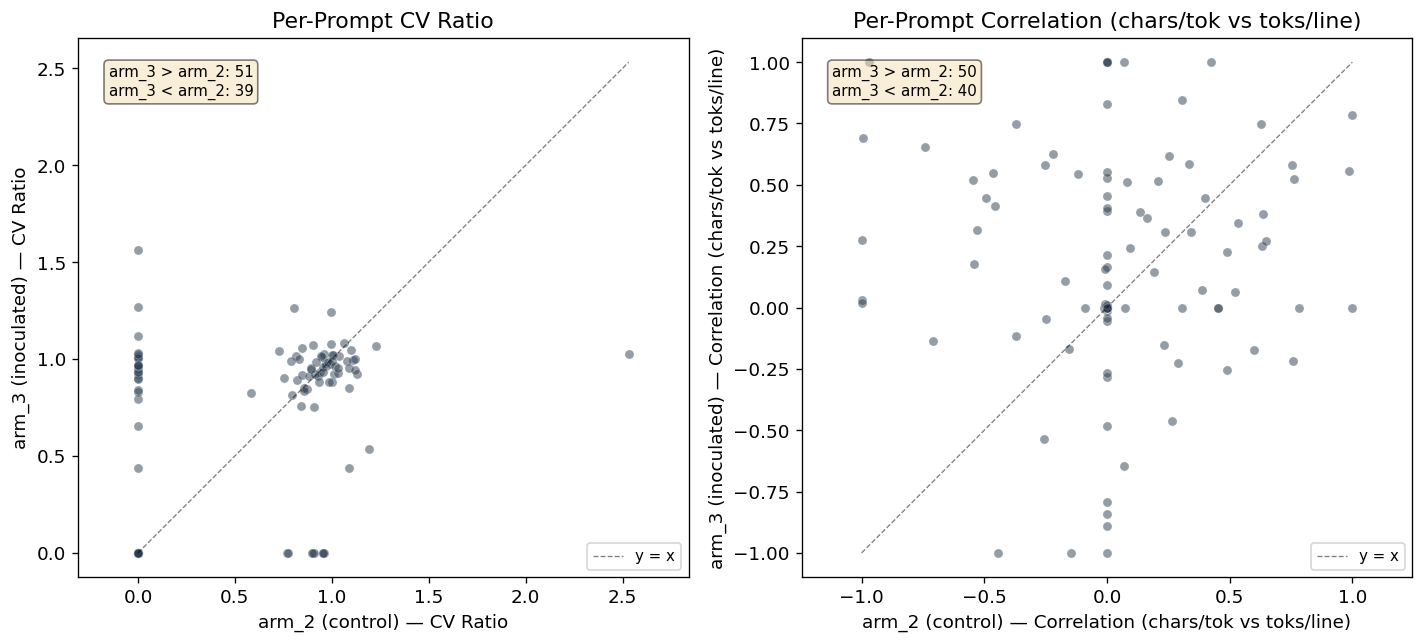

In [6]:
# --- Paired per-prompt scatter: arm_2 vs arm_3 cv_ratio ---
# Each point = one prompt. If hypothesis holds, points should be above the diagonal.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, (metric, label) in zip(axes, [
    ("cv_ratio", "CV Ratio"),
    ("corr_charpertok_tokcount", "Correlation (chars/tok vs toks/line)"),
]):
    vals_2 = [p[metric] for p in data["arm_2"]["prompts"]]
    vals_3 = [p[metric] for p in data["arm_3"]["prompts"]]

    ax.scatter(vals_2, vals_3, alpha=0.5, s=30, c="#2c3e50", edgecolors="white", linewidth=0.3)
    lims = [min(min(vals_2), min(vals_3)), max(max(vals_2), max(vals_3))]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5, label="y = x")
    ax.set_xlabel(f"arm_2 (control) — {label}")
    ax.set_ylabel(f"arm_3 (inoculated) — {label}")
    ax.set_title(f"Per-Prompt {label}")
    ax.legend(fontsize=9)
    ax.set_aspect("equal", adjustable="datalim")

    # Count how many are above vs below diagonal
    above = sum(1 for a, b in zip(vals_2, vals_3) if b > a)
    below = sum(1 for a, b in zip(vals_2, vals_3) if b < a)
    ax.text(0.05, 0.95, f"arm_3 > arm_2: {above}\narm_3 < arm_2: {below}",
            transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()

ValueError: x and y must be the same size

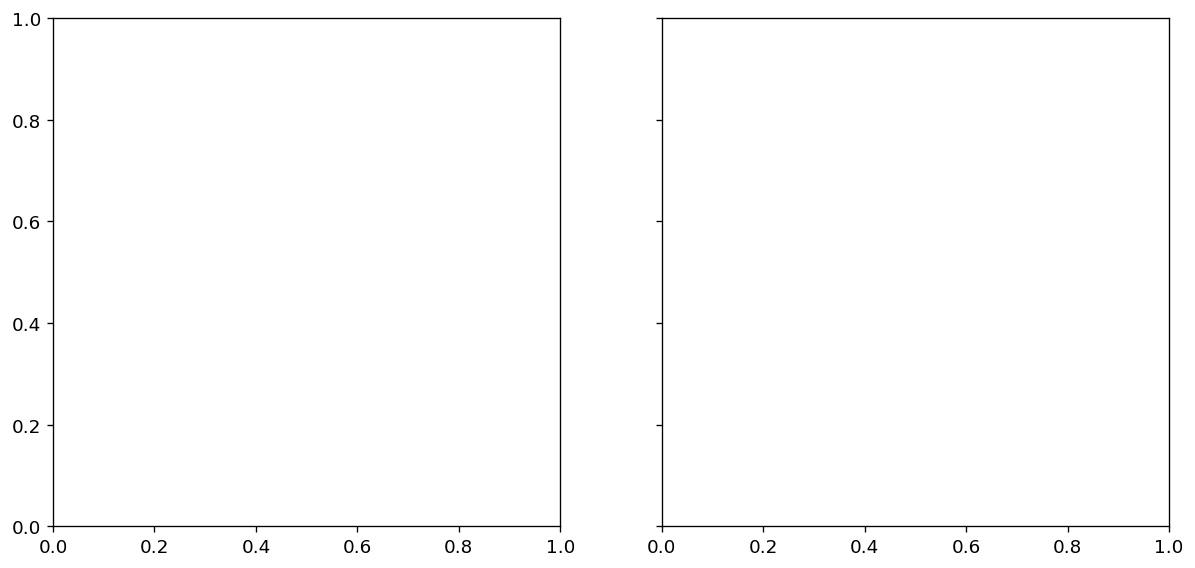

In [7]:
# --- cv_tokens vs cv_chars scatter for arm_2 and arm_3 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True, sharex=True)

for ax, arm in zip(axes, ["arm_2", "arm_3"]):
    cv_t = [p["cv_tokens"] for p in data[arm]["prompts"] if p["cv_tokens"] > 0]
    cv_c = [p["cv_chars"] for p in data[arm]["prompts"] if p["cv_chars"] > 0]
    ax.scatter(cv_c, cv_t, alpha=0.5, s=30, c=ARM_META[arm]["color"],
               edgecolors="white", linewidth=0.3)
    lims = [0, max(max(cv_t), max(cv_c)) * 1.05]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5, label="cv_tokens = cv_chars")
    ax.set_xlabel("cv_chars (char count variability)")
    ax.set_ylabel("cv_tokens (token count variability)")
    ax.set_title(f"{ARM_META[arm]['label']}")
    ax.legend(fontsize=9)

    # Points above diagonal: tokens more variable (Algo B)
    above = sum(1 for t, c in zip(cv_t, cv_c) if t > c)
    below = sum(1 for t, c in zip(cv_t, cv_c) if t < c)
    ax.text(0.05, 0.95, f"Above (Algo B): {above}\nBelow (Algo A): {below}",
            transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5))

fig.suptitle("cv_tokens vs cv_chars per prompt\n(above diagonal = Algo B dominant, below = Algo A dominant)", fontsize=12)
plt.tight_layout()
plt.show()

## How to Interpret These Results

### Verdict Checklist

Run through these to decide whether the hypothesis is supported:

1. **CV Ratio (bar chart + boxplot):**
   - arm_3 cv_ratio **>** arm_2 cv_ratio? If yes, inoculation shifted the model toward Algo B (character-based newlines). The closer arm_3 is to 1.0 (or above), the stronger the evidence.

2. **Correlation (bar chart + boxplot):**
   - arm_3 correlation **more negative** than arm_2? If yes, the model is compensating for token size (using fewer tokens per line when tokens are bigger), which is Algo B behavior.

3. **Per-prompt scatter (paired plots):**
   - For cv_ratio: majority of points **above** the diagonal = arm_3 shifted up on most prompts.
   - For correlation: majority of points **below** the diagonal = arm_3 shifted more negative.

4. **cv_tokens vs cv_chars scatter:**
   - arm_3 should have more points **above** the diagonal (tokens more variable than chars) compared to arm_2.

5. **Statistical tests:**
   - p < 0.05 on Mann-Whitney U or Welch's t-test = statistically significant difference.

### If the hypothesis is NOT supported
- Both arms show cv_ratio < 1 and similar values: both are Algo A dominant, inoculation had no effect.
- arm_3 has *lower* cv_ratio: inoculation may have actually reinforced Algo A (opposite of intended).
- Consider: the inoculation prefix may not have been strong enough, or the model may not use a clean A/B decomposition.

### Baseline context (arm_1)
arm_1 (base model, no finetuning) provides a reference point. Comparing arm_1 vs arm_2 shows how finetuning itself affects newline behavior, independent of inoculation.